EVALUASI SPATIAL FILTERING UNTUK RESTORASI CITRA


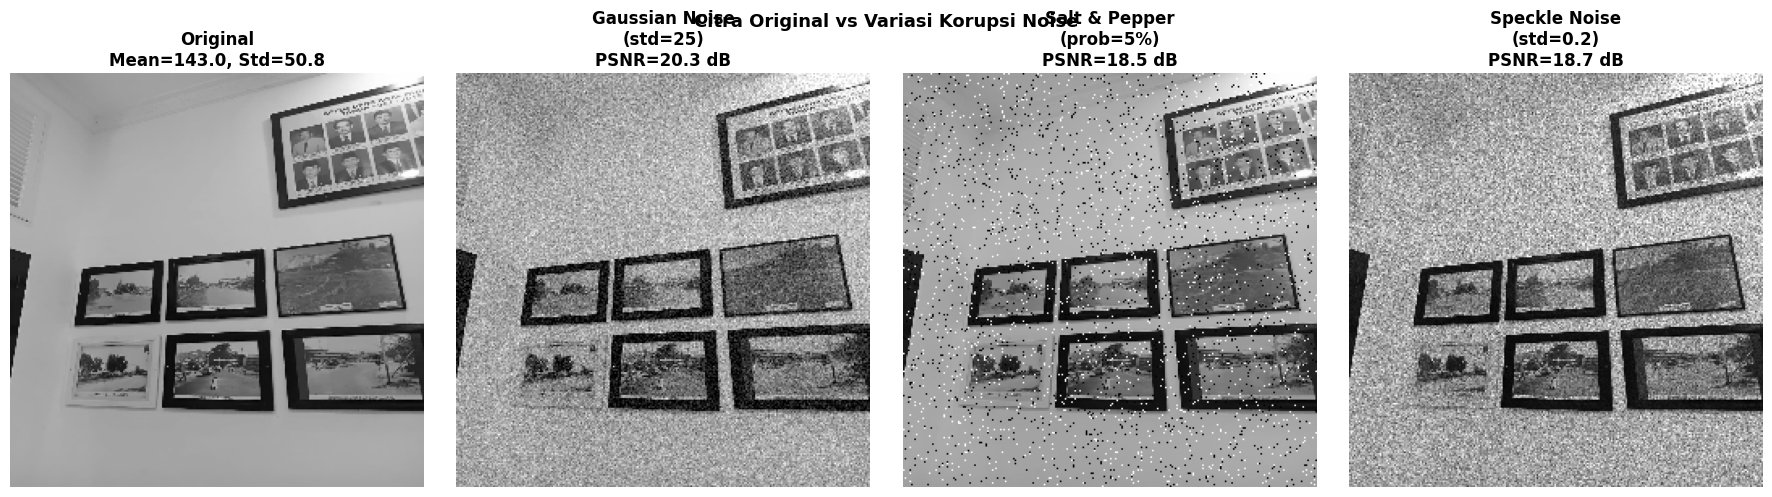


EVALUASI FILTER — GAUSSIAN NOISE

  Teknik                         MSE   PSNR(dB)     SSIM   Time(ms)
  ---------------------------------------------------------------
  Noisy (no filter)           605.40      20.31   0.3672     0.0013
  Mean 3×3                    273.44      23.76   0.6192     6.3993
  Mean 7×7                    522.07      20.95   0.6775     0.1890
  Gaussian σ=1 (5×5)          232.34      24.47   0.6858    13.1297
  Gaussian σ=2 (9×9)          414.48      21.96   0.7329     0.4583
  Median 3×3                  225.20      24.61   0.5794     2.1282
  Median 7×7                  347.91      22.72   0.7185     7.1901
  Min 3×3                    2614.35      13.96   0.3187     2.5314
  Max 3×3                    2617.15      13.95   0.3616     0.1266


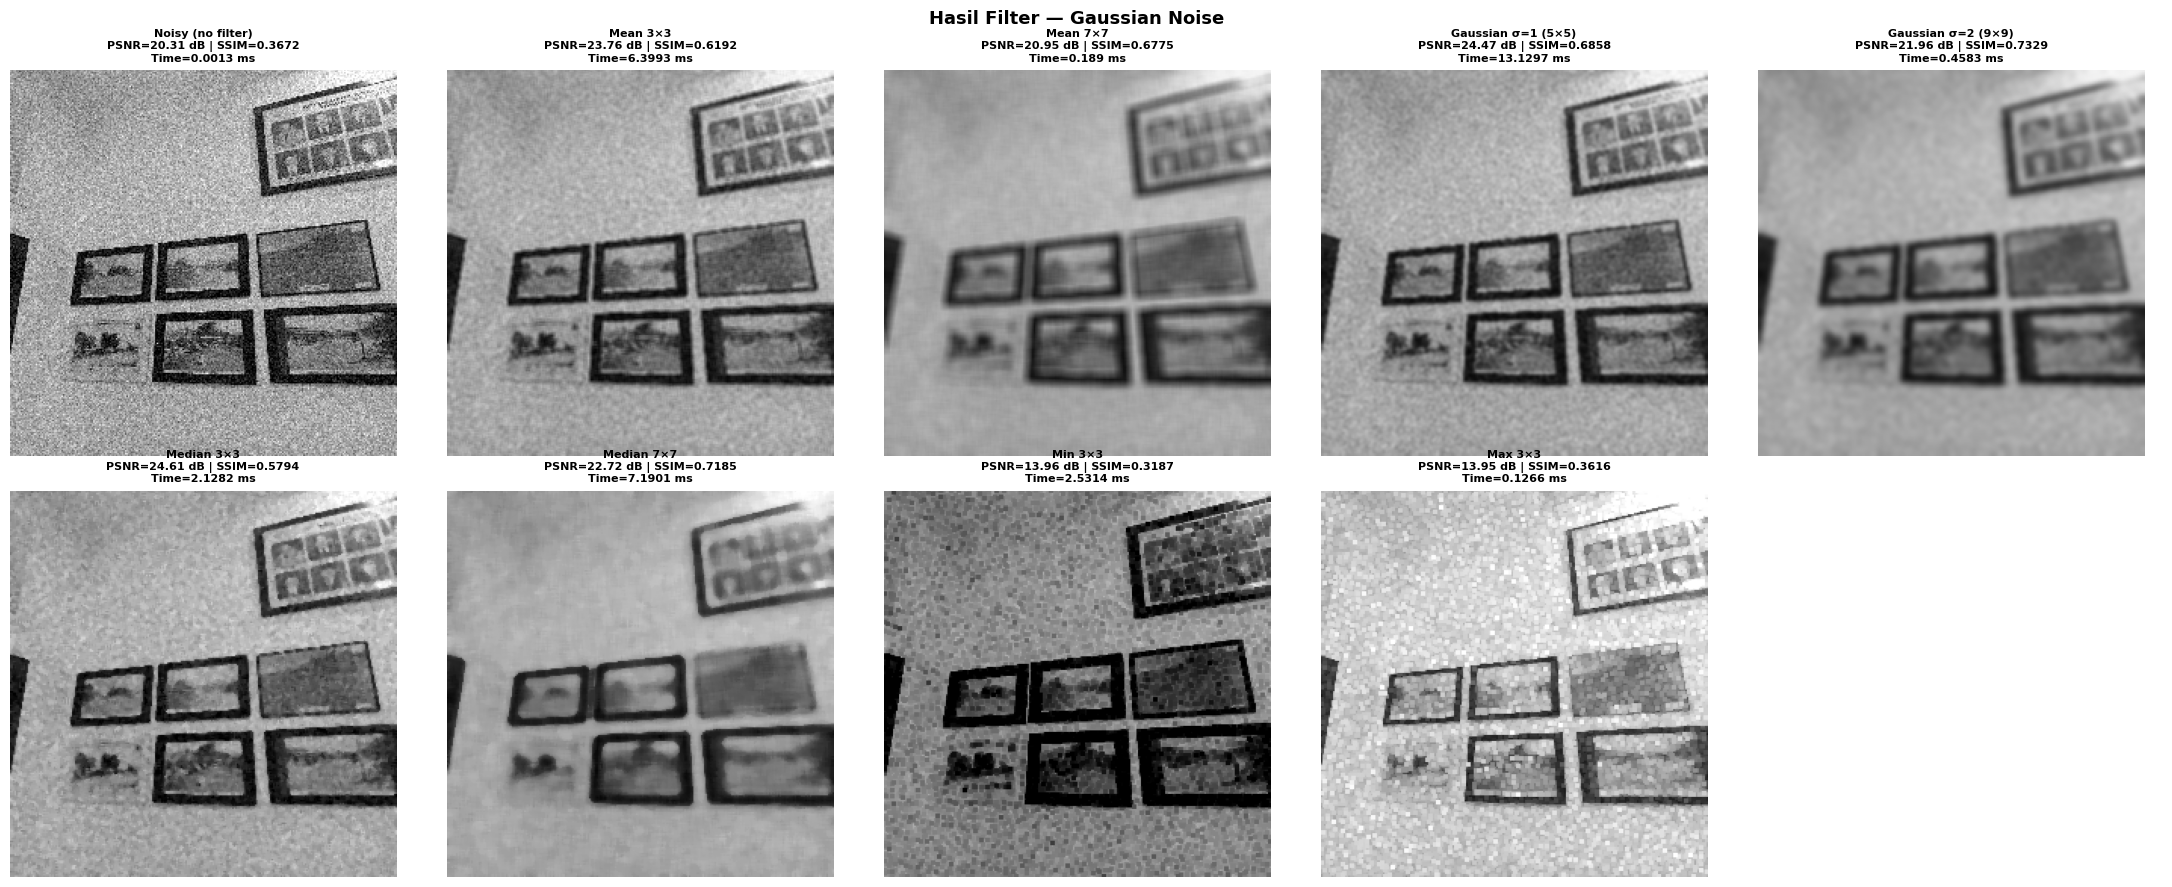

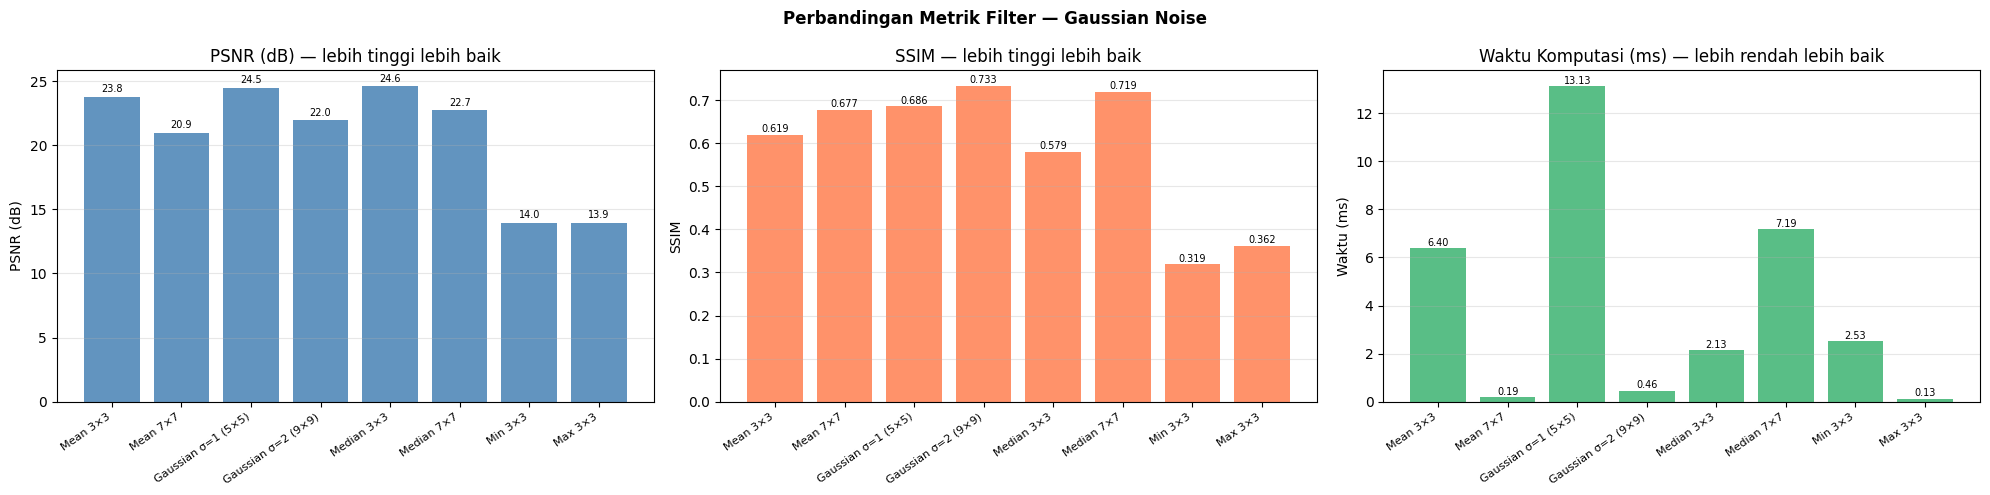


EVALUASI FILTER — SALT-AND-PEPPER NOISE

  Teknik                         MSE   PSNR(dB)     SSIM   Time(ms)
  ---------------------------------------------------------------
  Noisy (no filter)           916.61      18.51   0.4162     0.0014
  Mean 3×3                    319.01      23.09   0.5990     0.1315
  Mean 7×7                    542.44      20.79   0.6584     0.2282
  Gaussian σ=1 (5×5)          271.35      23.80   0.6592     0.1352
  Gaussian σ=2 (9×9)          436.69      21.73   0.7120     0.3404
  Median 3×3                  110.16      27.71   0.9214     0.0680
  Median 7×7                  295.29      23.43   0.8270     5.9169
  Min 3×3                    5282.18      10.90   0.1766     0.1022
  Max 3×3                    3729.08      12.41   0.2154     0.0858


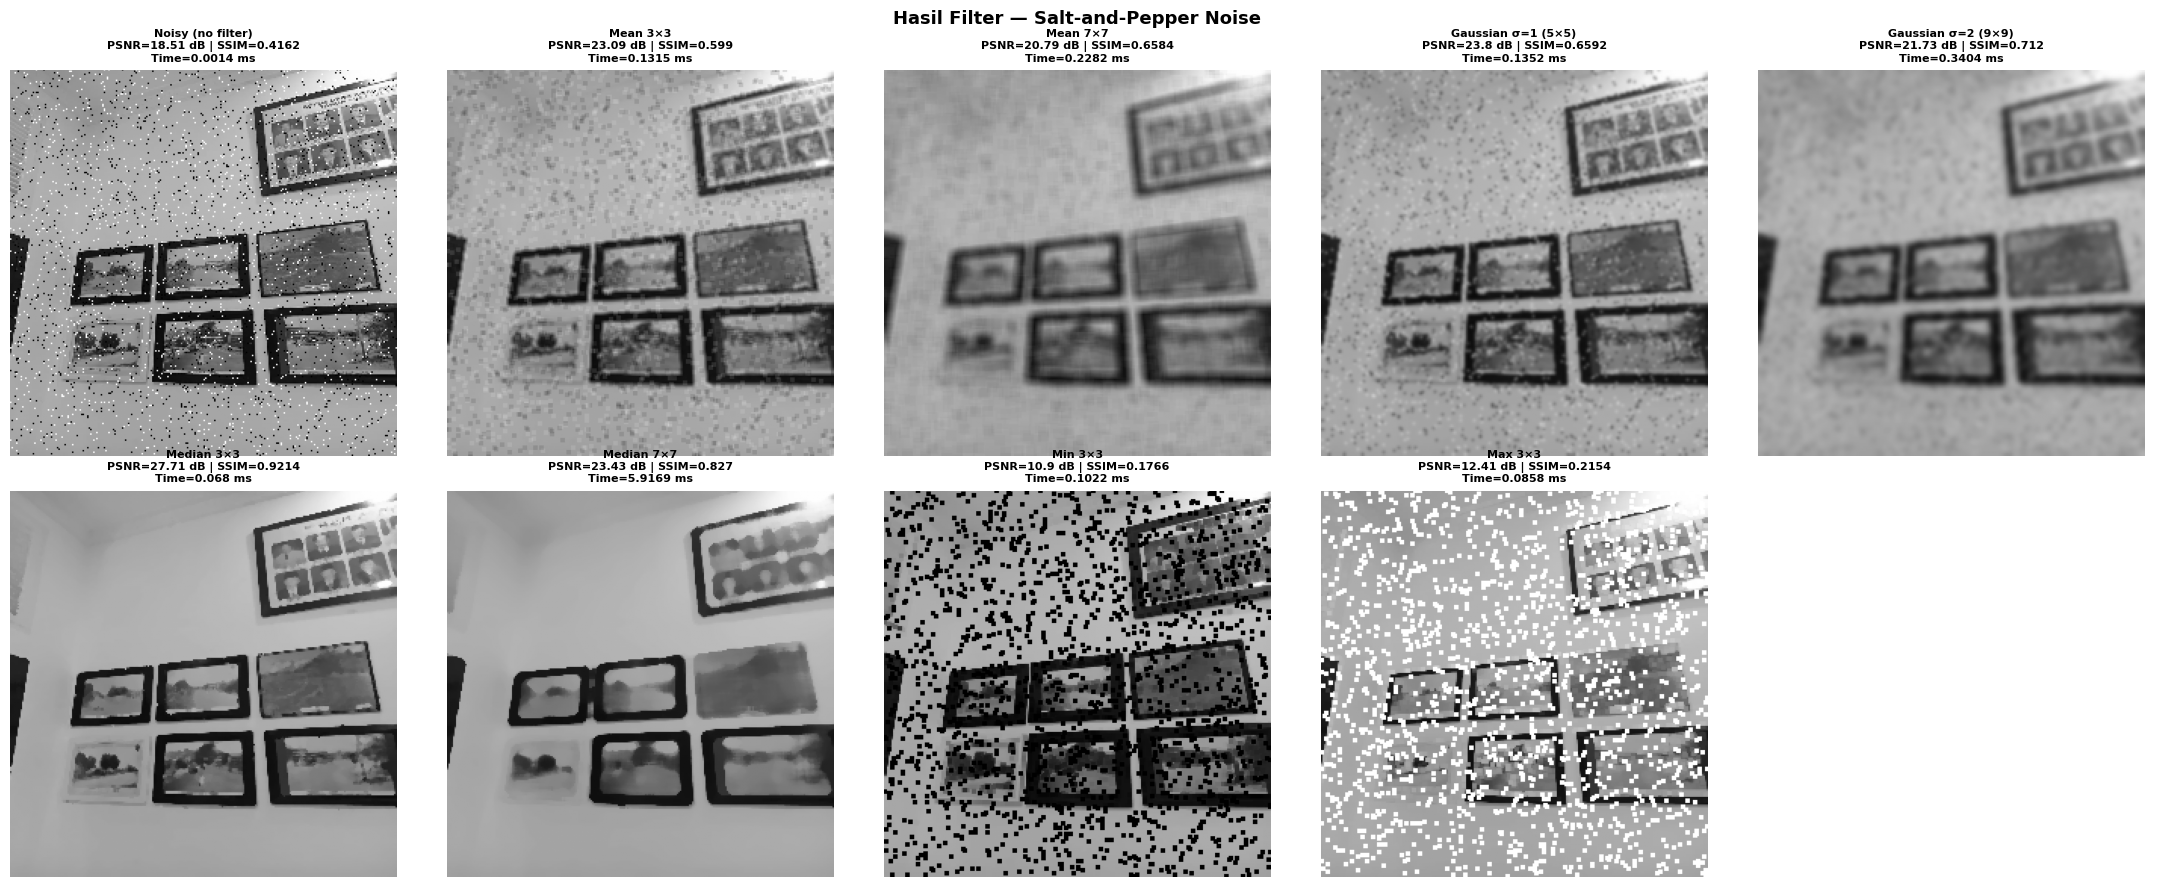

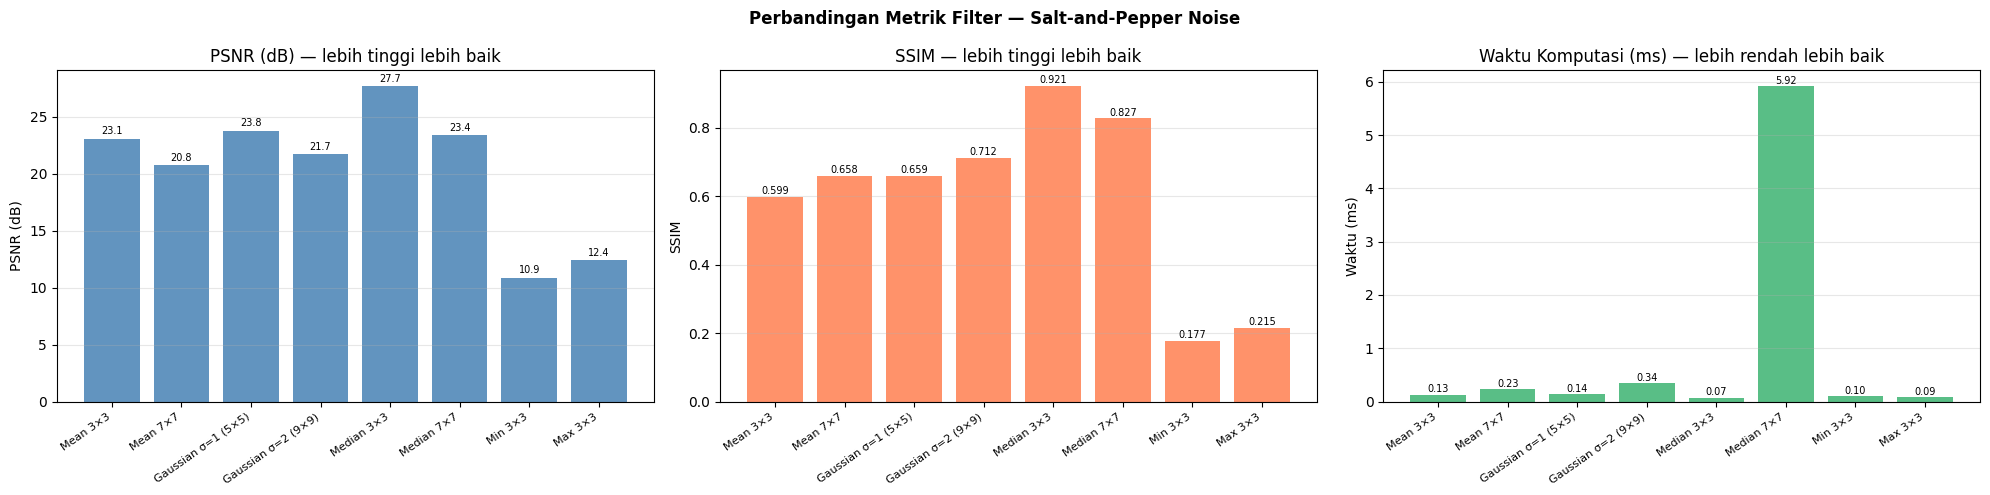


EVALUASI FILTER — SPECKLE NOISE

  Teknik                         MSE   PSNR(dB)     SSIM   Time(ms)
  ---------------------------------------------------------------
  Noisy (no filter)           887.29      18.65   0.3568     0.0011
  Mean 3×3                    304.19      23.30   0.5473     0.1544
  Mean 7×7                    524.08      20.94   0.6542     0.2308
  Gaussian σ=1 (5×5)          253.08      24.10   0.6175     1.6423
  Gaussian σ=2 (9×9)          415.94      21.94   0.7113     2.4453
  Median 3×3                  268.82      23.84   0.5186     0.0753
  Median 7×7                  353.74      22.64   0.6900     5.4764
  Min 3×3                    3265.49      12.99   0.2704     0.1065
  Max 3×3                    3388.14      12.83   0.3171     0.1053


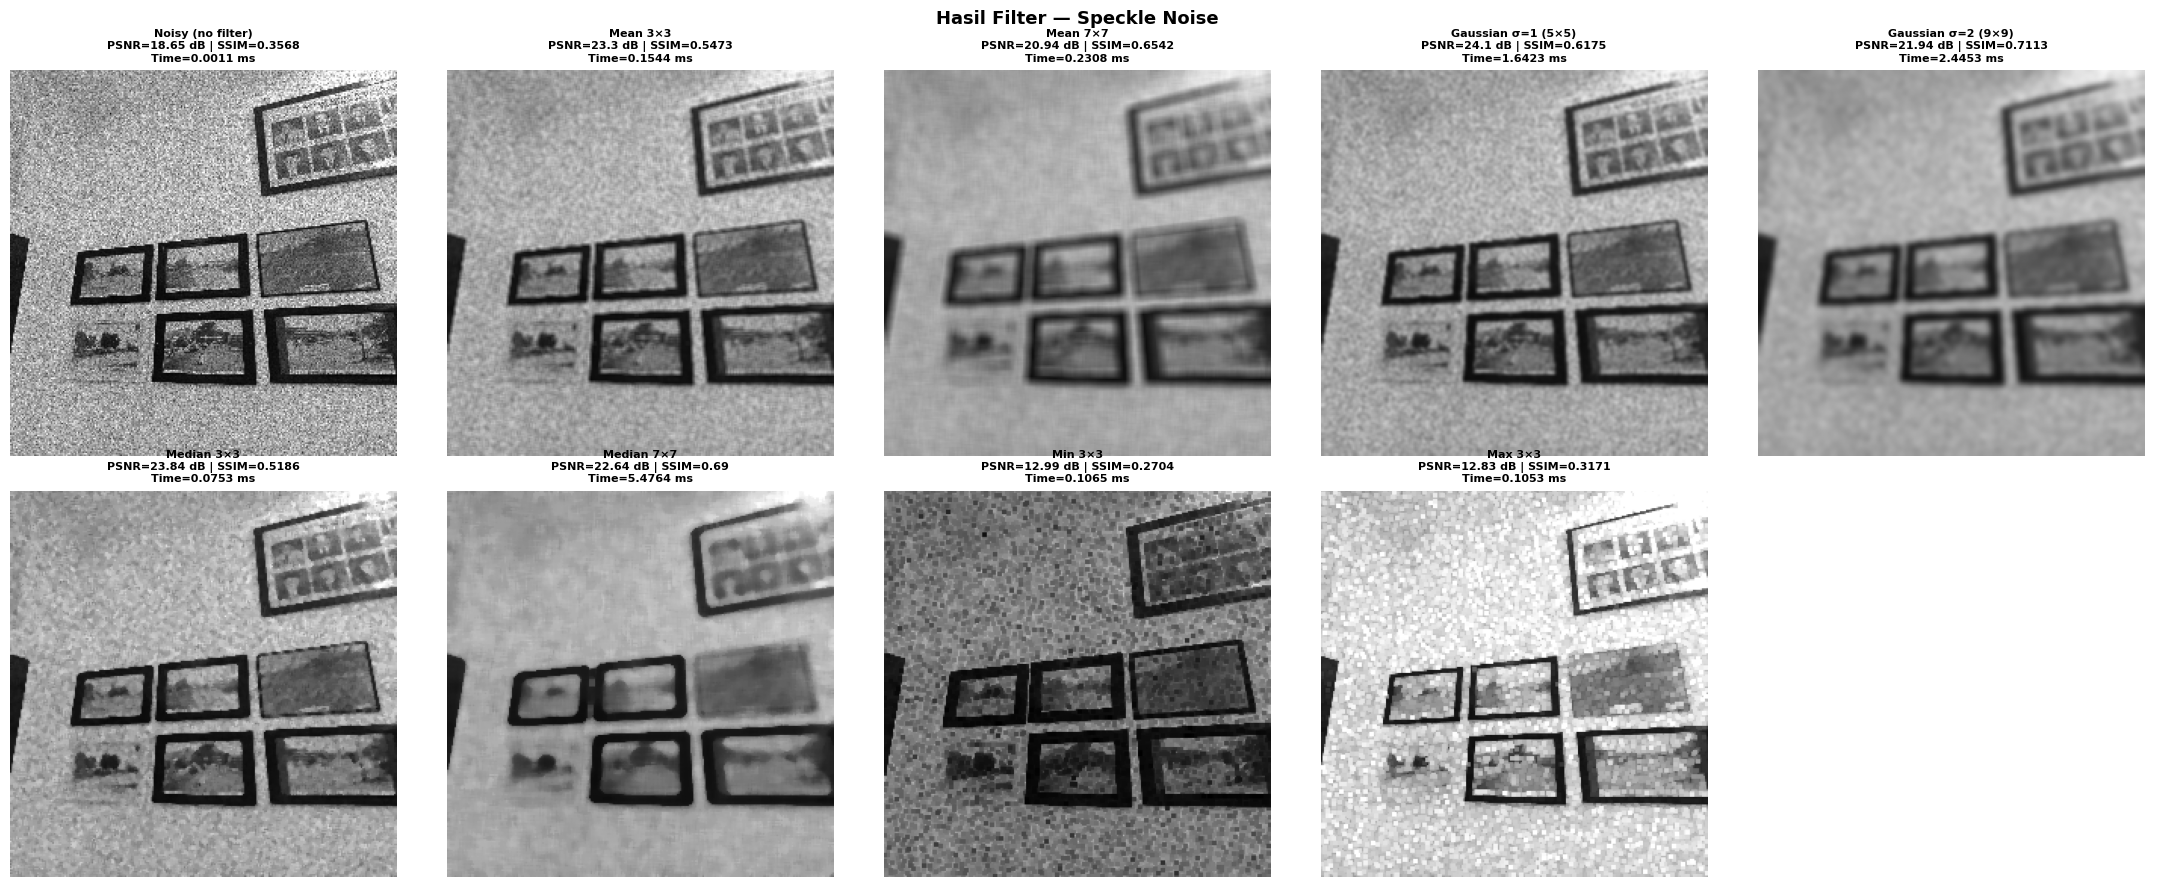

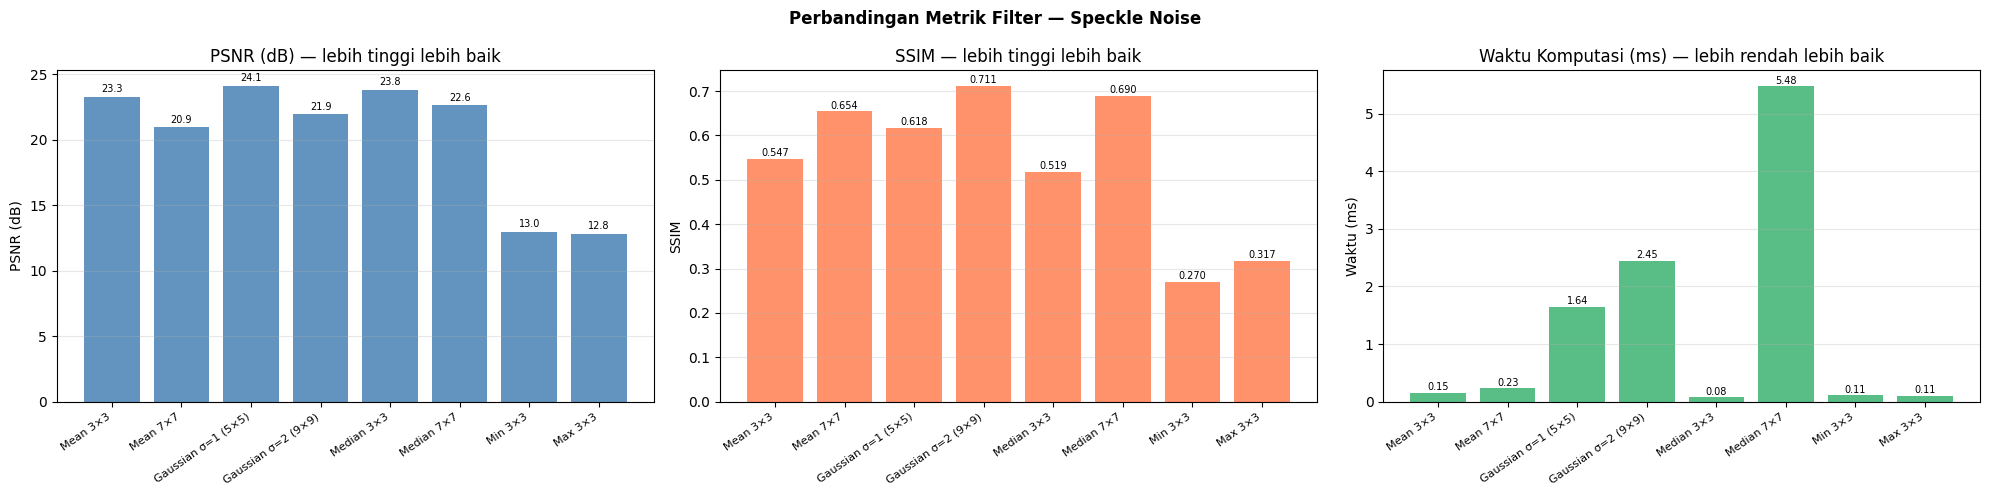


ANALISIS TRADE-OFF KERNEL SIZE vs KUALITAS vs KECEPATAN

Mean Filter (Gaussian noise):
  Kernel         PSNR     SSIM   Time(ms)
  --------------------------------------
  3x3           23.76   0.6192     0.1786
  5x5           22.25   0.6893     0.1364
  7x7           20.95   0.6775     0.2376
  9x9           19.88   0.6479     0.1988
  11x11         18.94   0.6150     0.2247
  15x15         17.65   0.5628     0.2706

Gaussian Filter (Gaussian noise):
  Kernel         PSNR     SSIM   Time(ms)
  --------------------------------------
  3x3           24.62   0.6296     0.1487
  5x5           23.22   0.7197     0.2304
  7x7           21.94   0.7234     0.4951
  9x9           20.93   0.7017     0.5746
  11x11         20.01   0.6708     1.3572
  15x15         18.66   0.6169     1.7632

Median Filter (Salt-and-pepper noise):
  Kernel         PSNR     SSIM   Time(ms)
  --------------------------------------
  3x3           27.71   0.9214     0.0796
  5x5           25.03   0.8663     0.5303


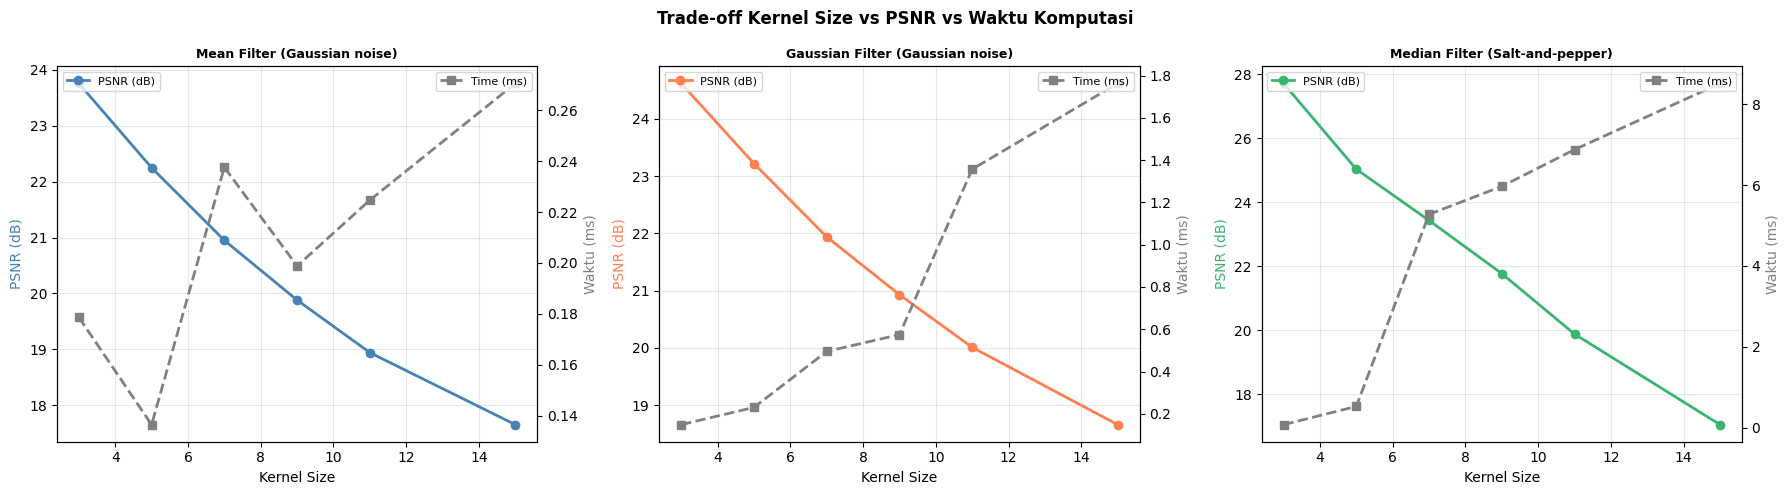


REKOMENDASI PIPELINE RESTORASI

Pipeline Gaussian Noise — Gaussian Filter → Normalisasi:
  Step                          PSNR     SSIM
  -------------------------------------------
  Noisy                        20.31   0.3672
  Gaussian σ=1                 24.47   0.6858
  + CS Manual                  24.54   0.6796


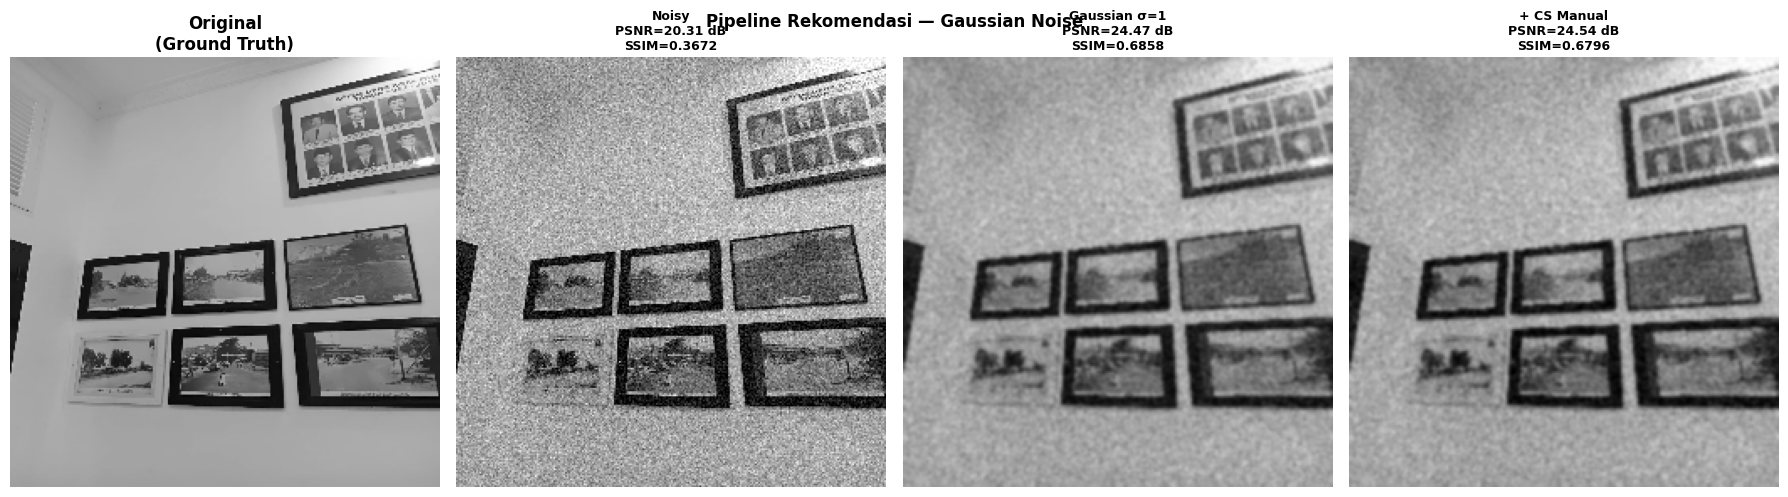


Pipeline Salt-and-Pepper Noise — Median Filter → Gaussian ringan:
  Step                          PSNR     SSIM
  -------------------------------------------
  Noisy                        18.51   0.4162
  Median 3×3                   27.71   0.9214
  + Gaussian σ=1               27.39   0.9153


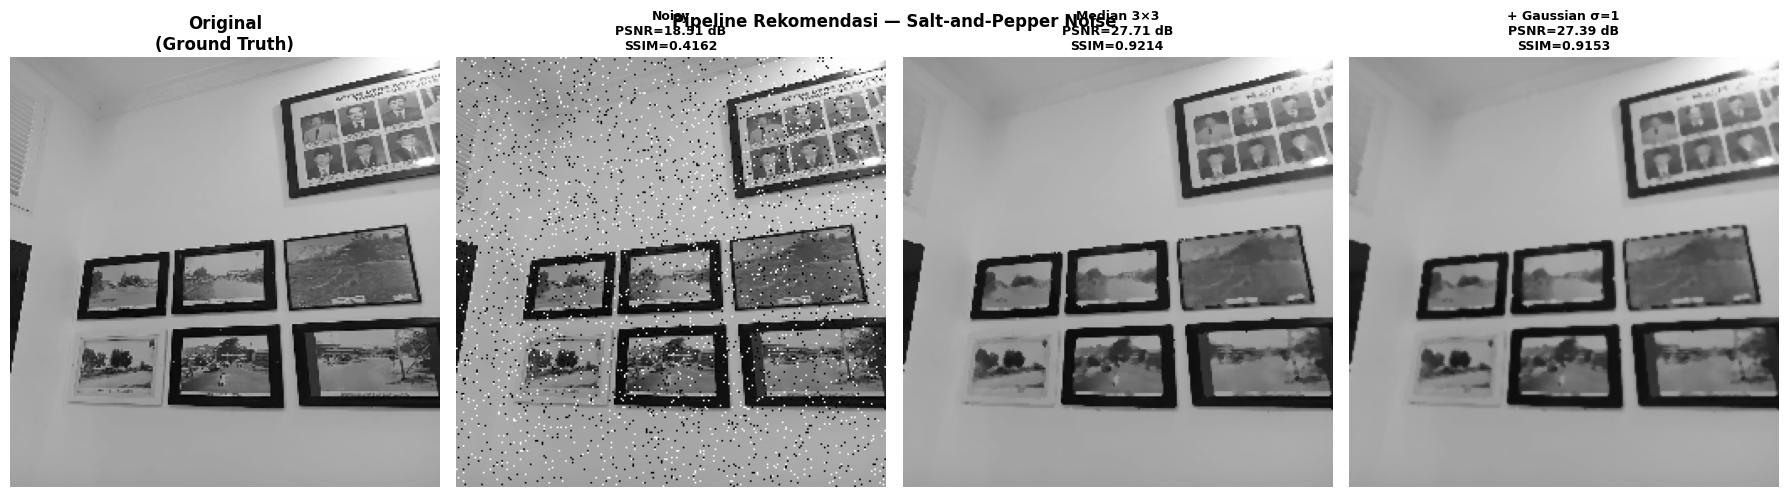


Pipeline Speckle Noise — Median Filter → Gaussian Filter:
  Step                          PSNR     SSIM
  -------------------------------------------
  Noisy                        18.65   0.3568
  Median 3×3                   23.84   0.5186
  + Gaussian σ=1               23.69   0.6591


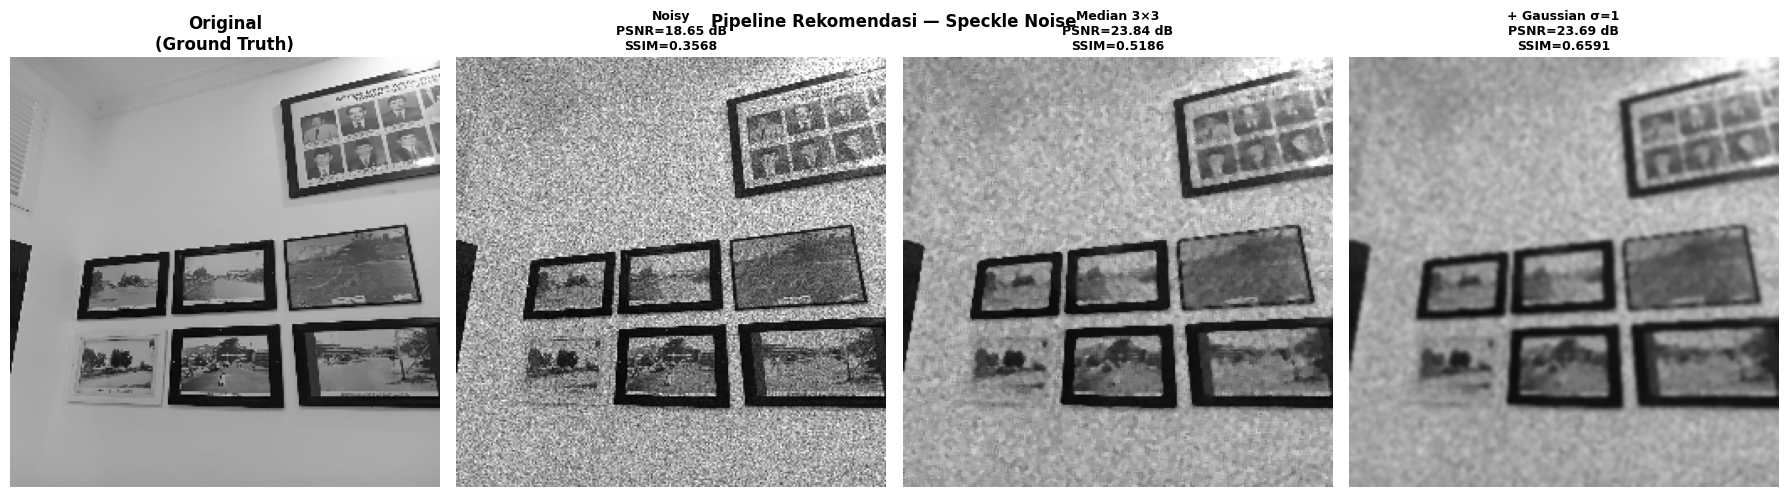


RINGKASAN: FILTER TERBAIK PER JENIS NOISE

  Noise                Filter Terbaik                PSNR     SSIM
  -----------------------------------------------------------------
  Gaussian Noise       Median 3×3                   24.61   0.5794
  Salt-and-Pepper      Median 3×3                   27.71   0.9214
  Speckle Noise        Gaussian σ=1 (5×5)           24.10   0.6175

Rekomendasi Umum:
  Gaussian noise    → Gaussian filter (σ sesuaikan dengan std noise)
  Salt-and-pepper   → Median filter (kernel 3×3 atau 5×5)
  Speckle noise     → Median + Gaussian (pipeline dua tahap)
  Mixed noise       → Median dulu → Gaussian, atau Bilateral filter

Trade-off Kernel:
  Kecil (3×3)  → Cepat, detail terjaga, noise reduction moderat
  Besar (7×7+) → Lambat, noise reduction kuat, tepi lebih blur
    

SELESAI


In [ ]:
# ============================================================
# TUGAS: Evaluasi Spatial Filtering untuk Restorasi Citra
# Judul: Evaluasi Spatial Filtering untuk Restorasi Citra
#        Terkorupsi Noise
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import time
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# BAGIAN 1: PERSIAPAN CITRA DAN KORUPSI NOISE
# ============================================================

def load_and_prepare(image_path, size=256):
    """Load foto asli dan resize."""
    img = cv2.imread(image_path)
    if img is None:
        print(f"File '{image_path}' tidak ditemukan, menggunakan citra sintetik.")
        return create_synthetic_image(size)
    img = cv2.resize(img, (size, size))
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


def create_synthetic_image(size=256):
    """Buat citra sintetik sebagai fallback."""
    img = np.zeros((size, size), dtype=np.uint8)
    cv2.rectangle(img, (30, 30), (120, 120), 180, -1)
    cv2.circle(img, (190, 70), 40, 220, -1)
    cv2.ellipse(img, (128, 200), (80, 40), 0, 0, 360, 150, -1)
    cv2.line(img, (0, 128), (256, 128), 100, 2)
    cv2.line(img, (128, 0), (128, 256), 100, 2)
    for i in range(0, size, 32):
        cv2.line(img, (i, 0), (i, size), 60, 1)
    return img


def add_gaussian_noise(image, mean=0, std=25):
    """Tambahkan Gaussian noise."""
    noise = np.random.normal(mean, std, image.shape)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def add_salt_pepper_noise(image, prob=0.05):
    """Tambahkan salt-and-pepper noise."""
    noisy = image.copy()
    total = image.size
    # Salt
    n_salt = int(total * prob / 2)
    coords = [np.random.randint(0, i, n_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    # Pepper
    n_pepper = int(total * prob / 2)
    coords = [np.random.randint(0, i, n_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy


def add_speckle_noise(image, std=0.2):
    """Tambahkan speckle noise (multiplicative)."""
    noise = np.random.normal(0, std, image.shape)
    noisy = image.astype(np.float32) * (1 + noise)
    return np.clip(noisy, 0, 255).astype(np.uint8)


def show_noisy_images(clean, noisy_dict):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(clean, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'Original\nMean={clean.mean():.1f}, Std={clean.std():.1f}',
                      fontweight='bold')
    axes[0].axis('off')

    titles = ['Gaussian Noise\n(std=25)',
              'Salt & Pepper\n(prob=5%)',
              'Speckle Noise\n(std=0.2)']
    for ax, (name, img), title in zip(axes[1:], noisy_dict.items(), titles):
        mse = np.mean((clean.astype(float) - img.astype(float))**2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{title}\nPSNR={psnr:.1f} dB', fontweight='bold')
        ax.axis('off')

    plt.suptitle('Citra Original vs Variasi Korupsi Noise',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================
# BAGIAN 2: IMPLEMENTASI FILTER
# ============================================================

def mean_filter(image, ksize):
    """Mean filter dengan kernel ksize x ksize."""
    return cv2.blur(image, (ksize, ksize))


def gaussian_filter(image, ksize, sigma):
    """Gaussian filter dengan kernel dan sigma tertentu."""
    # ksize harus ganjil
    k = ksize if ksize % 2 == 1 else ksize + 1
    return cv2.GaussianBlur(image, (k, k), sigma)


def median_filter(image, ksize):
    """Median filter dengan kernel ksize x ksize."""
    return cv2.medianBlur(image, ksize)


def min_filter(image, ksize):
    """Min filter menggunakan erosi morfologi."""
    kernel = np.ones((ksize, ksize), np.uint8)
    return cv2.erode(image, kernel)


def max_filter(image, ksize):
    """Max filter menggunakan dilasi morfologi."""
    kernel = np.ones((ksize, ksize), np.uint8)
    return cv2.dilate(image, kernel)


# ============================================================
# BAGIAN 3: METRIK EVALUASI
# ============================================================

def compute_ssim(img1, img2):
    """Hitung SSIM antara dua citra."""
    C1 = (0.01 * 255) ** 2
    C2 = (0.03 * 255) ** 2
    i1 = img1.astype(np.float64)
    i2 = img2.astype(np.float64)

    mu1 = cv2.GaussianBlur(i1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(i2, (11, 11), 1.5)

    mu1_sq  = mu1 ** 2
    mu2_sq  = mu2 ** 2
    mu1_mu2 = mu1 * mu2

    s1  = cv2.GaussianBlur(i1 * i1, (11, 11), 1.5) - mu1_sq
    s2  = cv2.GaussianBlur(i2 * i2, (11, 11), 1.5) - mu2_sq
    s12 = cv2.GaussianBlur(i1 * i2, (11, 11), 1.5) - mu1_mu2

    num = (2 * mu1_mu2 + C1) * (2 * s12 + C2)
    den = (mu1_sq + mu2_sq + C1) * (s1 + s2 + C2)
    return float(np.mean(num / den))


def compute_all_metrics(clean, filtered, label=''):
    """Hitung MSE, PSNR, SSIM, dan waktu komputasi."""
    mse  = float(np.mean((clean.astype(float) - filtered.astype(float))**2))
    psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
    ssim = compute_ssim(clean, filtered)
    return {
        'label': label,
        'mse'  : round(mse,  2),
        'psnr' : round(psnr, 2),
        'ssim' : round(ssim, 4),
    }


def apply_and_time(func, image, *args):
    """Jalankan fungsi filter dan ukur waktunya."""
    t0 = time.perf_counter()
    result = func(image, *args)
    elapsed = (time.perf_counter() - t0) * 1000
    return result, round(elapsed, 4)


# ============================================================
# BAGIAN 4: EVALUASI PER JENIS NOISE
# ============================================================

def evaluate_filters(clean, noisy, noise_type):
    """
    Terapkan semua filter ke satu jenis noise dan evaluasi.
    Returns dict hasil dan tabel metrik.
    """
    print(f"\n{'='*65}")
    print(f"EVALUASI FILTER — {noise_type.upper()}")
    print(f"{'='*65}")

    filter_configs = {
        'Noisy (no filter)'   : (lambda img: img,                    []),
        'Mean 3×3'            : (mean_filter,                         [3]),
        'Mean 7×7'            : (mean_filter,                         [7]),
        'Gaussian σ=1 (5×5)'  : (gaussian_filter,                    [5, 1]),
        'Gaussian σ=2 (9×9)'  : (gaussian_filter,                    [9, 2]),
        'Median 3×3'          : (median_filter,                       [3]),
        'Median 7×7'          : (median_filter,                       [7]),
        'Min 3×3'             : (min_filter,                          [3]),
        'Max 3×3'             : (max_filter,                          [3]),
    }

    results    = {}
    metrics    = []

    for label, (fn, args) in filter_configs.items():
        filtered, elapsed = apply_and_time(fn, noisy, *args)
        m = compute_all_metrics(clean, filtered, label)
        m['time_ms'] = elapsed
        metrics.append(m)
        results[label] = filtered

    # Cetak tabel
    print(f"\n  {'Teknik':<25} {'MSE':>8} {'PSNR(dB)':>10} {'SSIM':>8} {'Time(ms)':>10}")
    print(f"  {'-'*63}")
    for m in metrics:
        print(f"  {m['label']:<25} {m['mse']:>8.2f} {m['psnr']:>10.2f} "
              f"{m['ssim']:>8.4f} {m['time_ms']:>10.4f}")

    return results, metrics


def visualize_filter_results(clean, noisy, results, metrics, noise_type):
    """Visualisasi semua hasil filter untuk satu jenis noise."""
    n = len(results)
    cols = 5
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 4.5))
    axes = axes.ravel()

    for idx, (label, img) in enumerate(results.items()):
        m = metrics[idx]
        axes[idx].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[idx].set_title(
            f'{label}\nPSNR={m["psnr"]} dB | SSIM={m["ssim"]}\nTime={m["time_ms"]} ms',
            fontsize=8, fontweight='bold')
        axes[idx].axis('off')

    # Sembunyikan subplot kosong
    for idx in range(len(results), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Hasil Filter — {noise_type}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Bar chart PSNR dan SSIM
    labels    = [m['label'] for m in metrics[1:]]  # skip noisy
    psnr_vals = [m['psnr']  for m in metrics[1:]]
    ssim_vals = [m['ssim']  for m in metrics[1:]]
    time_vals = [m['time_ms'] for m in metrics[1:]]

    fig, axes2 = plt.subplots(1, 3, figsize=(20, 5))
    x = np.arange(len(labels))

    # PSNR
    bars = axes2[0].bar(x, psnr_vals, color='steelblue', alpha=0.85)
    axes2[0].set_xticks(x); axes2[0].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    axes2[0].set_title('PSNR (dB) — lebih tinggi lebih baik')
    axes2[0].set_ylabel('PSNR (dB)'); axes2[0].grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, psnr_vals):
        axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                      f'{v:.1f}', ha='center', va='bottom', fontsize=7)

    # SSIM
    bars2 = axes2[1].bar(x, ssim_vals, color='coral', alpha=0.85)
    axes2[1].set_xticks(x); axes2[1].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    axes2[1].set_title('SSIM — lebih tinggi lebih baik')
    axes2[1].set_ylabel('SSIM'); axes2[1].grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars2, ssim_vals):
        axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                      f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    # Waktu komputasi
    bars3 = axes2[2].bar(x, time_vals, color='mediumseagreen', alpha=0.85)
    axes2[2].set_xticks(x); axes2[2].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    axes2[2].set_title('Waktu Komputasi (ms) — lebih rendah lebih baik')
    axes2[2].set_ylabel('Waktu (ms)'); axes2[2].grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars3, time_vals):
        axes2[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{v:.2f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle(f'Perbandingan Metrik Filter — {noise_type}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================
# BAGIAN 5: ANALISIS KERNEL SIZE vs KUALITAS vs KECEPATAN
# ============================================================

def kernel_tradeoff_analysis(clean, noisy_gaussian, noisy_sp):
    """Analisis trade-off ukuran kernel vs kualitas vs kecepatan."""
    print("\n" + "=" * 65)
    print("ANALISIS TRADE-OFF KERNEL SIZE vs KUALITAS vs KECEPATAN")
    print("=" * 65)

    kernel_sizes = [3, 5, 7, 9, 11, 15]

    mean_metrics    = []
    gaussian_metrics = []
    median_metrics  = []

    for k in kernel_sizes:
        # Mean
        r, t = apply_and_time(mean_filter, noisy_gaussian, k)
        m = compute_all_metrics(clean, r)
        mean_metrics.append({'k': k, 'psnr': m['psnr'], 'ssim': m['ssim'], 'time': t})

        # Gaussian
        r, t = apply_and_time(gaussian_filter, noisy_gaussian, k if k%2==1 else k+1, k/3)
        m = compute_all_metrics(clean, r)
        gaussian_metrics.append({'k': k, 'psnr': m['psnr'], 'ssim': m['ssim'], 'time': t})

        # Median (salt-and-pepper)
        ks = k if k % 2 == 1 else k + 1
        r, t = apply_and_time(median_filter, noisy_sp, ks)
        m = compute_all_metrics(clean, r)
        median_metrics.append({'k': ks, 'psnr': m['psnr'], 'ssim': m['ssim'], 'time': t})

    # Tabel
    print(f"\nMean Filter (Gaussian noise):")
    print(f"  {'Kernel':<10} {'PSNR':>8} {'SSIM':>8} {'Time(ms)':>10}")
    print(f"  {'-'*38}")
    for m in mean_metrics:
        print(f"  {str(m['k'])+'x'+str(m['k']):<10} {m['psnr']:>8.2f} {m['ssim']:>8.4f} {m['time']:>10.4f}")

    print(f"\nGaussian Filter (Gaussian noise):")
    print(f"  {'Kernel':<10} {'PSNR':>8} {'SSIM':>8} {'Time(ms)':>10}")
    print(f"  {'-'*38}")
    for m in gaussian_metrics:
        print(f"  {str(m['k'])+'x'+str(m['k']):<10} {m['psnr']:>8.2f} {m['ssim']:>8.4f} {m['time']:>10.4f}")

    print(f"\nMedian Filter (Salt-and-pepper noise):")
    print(f"  {'Kernel':<10} {'PSNR':>8} {'SSIM':>8} {'Time(ms)':>10}")
    print(f"  {'-'*38}")
    for m in median_metrics:
        print(f"  {str(m['k'])+'x'+str(m['k']):<10} {m['psnr']:>8.2f} {m['ssim']:>8.4f} {m['time']:>10.4f}")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, data, title, color in zip(
        axes,
        [mean_metrics, gaussian_metrics, median_metrics],
        ['Mean Filter (Gaussian noise)',
         'Gaussian Filter (Gaussian noise)',
         'Median Filter (Salt-and-pepper)'],
        ['steelblue', 'coral', 'mediumseagreen']
    ):
        ks     = [m['k']    for m in data]
        psnrs  = [m['psnr'] for m in data]
        times  = [m['time'] for m in data]

        ax2 = ax.twinx()
        ax.plot(ks, psnrs, 'o-', color=color,   linewidth=2, label='PSNR (dB)')
        ax2.plot(ks, times, 's--', color='gray', linewidth=2, label='Time (ms)')
        ax.set_xlabel('Kernel Size')
        ax.set_ylabel('PSNR (dB)', color=color)
        ax2.set_ylabel('Waktu (ms)', color='gray')
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', fontsize=8)
        ax2.legend(loc='upper right', fontsize=8)

    plt.suptitle('Trade-off Kernel Size vs PSNR vs Waktu Komputasi',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================
# BAGIAN 6: REKOMENDASI PIPELINE
# ============================================================

def pipeline_recommendation(clean, noisy_dict):
    """Pipeline restorasi terbaik per jenis noise."""
    print("\n" + "=" * 65)
    print("REKOMENDASI PIPELINE RESTORASI")
    print("=" * 65)

    pipelines = {
        'gaussian'    : {
            'steps': [
                ('Noisy',          lambda img: img),
                ('Gaussian σ=1',   lambda img: gaussian_filter(img, 5, 1)),
                ('+ CS Manual',    lambda img: cv2.normalize(
                                       gaussian_filter(img, 5, 1), None, 0, 255,
                                       cv2.NORM_MINMAX)),
            ],
            'desc': 'Gaussian Filter → Normalisasi'
        },
        'salt_pepper' : {
            'steps': [
                ('Noisy',          lambda img: img),
                ('Median 3×3',     lambda img: median_filter(img, 3)),
                ('+ Gaussian σ=1', lambda img: gaussian_filter(
                                       median_filter(img, 3), 3, 0.5)),
            ],
            'desc': 'Median Filter → Gaussian ringan'
        },
        'speckle'     : {
            'steps': [
                ('Noisy',          lambda img: img),
                ('Median 3×3',     lambda img: median_filter(img, 3)),
                ('+ Gaussian σ=1', lambda img: gaussian_filter(
                                       median_filter(img, 3), 5, 1)),
            ],
            'desc': 'Median Filter → Gaussian Filter'
        },
    }

    noise_labels = {
        'gaussian'   : 'Gaussian Noise',
        'salt_pepper': 'Salt-and-Pepper Noise',
        'speckle'    : 'Speckle Noise',
    }

    for noise_key, noisy in noisy_dict.items():
        pipe  = pipelines[noise_key]
        steps = pipe['steps']

        fig, axes = plt.subplots(1, len(steps) + 1, figsize=(18, 5))

        # Original
        axes[0].imshow(clean, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title('Original\n(Ground Truth)', fontweight='bold')
        axes[0].axis('off')

        print(f"\nPipeline {noise_labels[noise_key]} — {pipe['desc']}:")
        print(f"  {'Step':<25} {'PSNR':>8} {'SSIM':>8}")
        print(f"  {'-'*43}")

        for col, (step_name, fn) in enumerate(steps, start=1):
            result = fn(noisy)
            m = compute_all_metrics(clean, result)
            axes[col].imshow(result, cmap='gray', vmin=0, vmax=255)
            axes[col].set_title(
                f'{step_name}\nPSNR={m["psnr"]} dB\nSSIM={m["ssim"]}',
                fontweight='bold', fontsize=9)
            axes[col].axis('off')
            print(f"  {step_name:<25} {m['psnr']:>8.2f} {m['ssim']:>8.4f}")

        plt.suptitle(f'Pipeline Rekomendasi — {noise_labels[noise_key]}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


# ============================================================
# BAGIAN 7: RINGKASAN KOMPARATIF
# ============================================================

def final_summary(clean, noisy_dict, all_metrics):
    """Tampilkan ringkasan teknik terbaik per jenis noise."""
    print("\n" + "=" * 65)
    print("RINGKASAN: FILTER TERBAIK PER JENIS NOISE")
    print("=" * 65)

    noise_labels = {
        'gaussian'   : 'Gaussian Noise',
        'salt_pepper': 'Salt-and-Pepper',
        'speckle'    : 'Speckle Noise',
    }

    print(f"\n  {'Noise':<20} {'Filter Terbaik':<25} {'PSNR':>8} {'SSIM':>8}")
    print(f"  {'-'*65}")

    for noise_key, metrics in all_metrics.items():
        # Cari filter dengan PSNR tertinggi (skip index 0 = noisy)
        best = max(metrics[1:], key=lambda m: m['psnr'])
        print(f"  {noise_labels[noise_key]:<20} {best['label']:<25} "
              f"{best['psnr']:>8.2f} {best['ssim']:>8.4f}")

    print(f"""
Rekomendasi Umum:
  Gaussian noise    → Gaussian filter (σ sesuaikan dengan std noise)
  Salt-and-pepper   → Median filter (kernel 3×3 atau 5×5)
  Speckle noise     → Median + Gaussian (pipeline dua tahap)
  Mixed noise       → Median dulu → Gaussian, atau Bilateral filter

Trade-off Kernel:
  Kecil (3×3)  → Cepat, detail terjaga, noise reduction moderat
  Besar (7×7+) → Lambat, noise reduction kuat, tepi lebih blur
    """)


# ============================================================
# MAIN
# ============================================================

print("=" * 65)
print("EVALUASI SPATIAL FILTERING UNTUK RESTORASI CITRA")
print("=" * 65)

np.random.seed(42)

# Load atau buat citra
IMAGE_PATH = 'img5.jpeg'
clean = load_and_prepare(IMAGE_PATH, size=256)

# Buat 3 variasi noise
noisy_dict = {
    'gaussian'   : add_gaussian_noise(clean,    std=25),
    'salt_pepper': add_salt_pepper_noise(clean,  prob=0.05),
    'speckle'    : add_speckle_noise(clean,      std=0.2),
}

# Tampilkan citra original dan noisy
show_noisy_images(clean, noisy_dict)

# Evaluasi semua filter per jenis noise
all_metrics = {}
noise_labels = {
    'gaussian'   : 'Gaussian Noise',
    'salt_pepper': 'Salt-and-Pepper Noise',
    'speckle'    : 'Speckle Noise',
}

for noise_key, noisy in noisy_dict.items():
    results, metrics = evaluate_filters(clean, noisy, noise_labels[noise_key])
    all_metrics[noise_key] = metrics
    visualize_filter_results(clean, noisy, results, metrics, noise_labels[noise_key])

# Analisis trade-off kernel size
kernel_tradeoff_analysis(clean, noisy_dict['gaussian'], noisy_dict['salt_pepper'])

# Rekomendasi pipeline
pipeline_recommendation(clean, noisy_dict)

# Ringkasan final
final_summary(clean, noisy_dict, all_metrics)

print("\n" + "=" * 65)
print("SELESAI")
print("=" * 65)